# Proyecto Fin de Curso: Predicción de la Demanda Energética en España (2015-2018)

## HITO 3

**Estudiante:** Marta Requejo Merino 

**Especialidad:** Grado en IA y Big Data 

---

In [8]:
# System and Environment
import os

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - XGBoost (Solo para plot_importance)
import xgboost as xgb
from xgboost import plot_importance

# Persistence (Para cargar el modelo, escalador y variables)
import joblib

In [9]:
# Definimos las rutas subiendo un nivel desde /notebooks
BASE_DIR = os.path.dirname(os.getcwd())
MODELS_DIR = os.path.join(BASE_DIR, 'modelos')
PROCESSED_DIR = os.path.join(BASE_DIR, 'datos_procesados')

# Cargar el modelo .json
modelo_definitivo = xgb.XGBRegressor()
modelo_definitivo.load_model(os.path.join(MODELS_DIR, "modelo_energia_es_lag.json"))

# Cargar el escalador y variables
scaler_final = joblib.load(os.path.join(MODELS_DIR, "escalador_energia_es_lag.pkl"))
variables_ganadoras = joblib.load(os.path.join(MODELS_DIR, "variables_energia_es_lag.pkl"))

# Cargar datos de test
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_df_hito02.csv"))

## 7. Representación Gráfica del Modelo

Una vez que hemos comprobado con números que **XGBoost** es nuestro mejor modelo, el siguiente paso es ver cómo se comporta visualmente. Las métricas como el $R^2$ o el MAE nos dan una nota general, pero las gráficas nos ayudan a entender realmente **dónde acierta el modelo, dónde falla y cómo toma sus decisiones**.

Para analizarlo a fondo, hemos dividido este apartado en cuatro subpuntos:
1. Importancia de las variables.
2. Gráfico de dispersión (Real vs Predicho).
3. Zoom temporal a una semana.
4. Distribución de los errores.

In [10]:
# Configuración visual
sns.set_theme(style="whitegrid")

#Escalar SOLO los datos de test usando el escalador cargado
X_test_final = pd.DataFrame(scaler_final.transform(test_df[variables_ganadoras]), columns=variables_ganadoras)

# Separar la demanda real para poder compararla luego
y_test = test_df['total_load_actual'] 

# Generar las predicciones con el modelo cargado
y_pred_final = modelo_definitivo.predict(X_test_final)

print("¡Predicciones generadas con éxito!")

¡Predicciones generadas con éxito!


### 7.1. Importancia de las Variables

En este primer gráfico vamos a ver en qué variables se apoya más el modelo para calcular la demanda eléctrica. XGBoost mide cuántas veces se usa cada característica para dividir los datos y tomar una decisión (F-score).

<Figure size 1000x600 with 0 Axes>

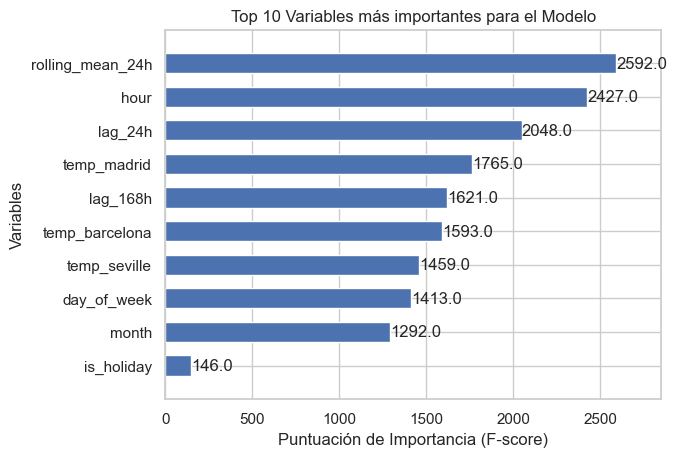

In [11]:
plt.figure(figsize=(10, 6))
plot_importance(modelo_definitivo, max_num_features=10, height=0.6,
                title="Top 10 Variables más importantes para el Modelo",
                xlabel="Puntuación de Importancia (F-score)", ylabel="Variables")
plt.show()

**Conclusión del gráfico:**
Como se puede ver, las variables que miran al pasado (los *lags*) y la temperatura de Madrid son las auténticas "estrellas" del modelo. Esto tiene todo el sentido del mundo: para saber cuánta luz se va a gastar hoy a una hora concreta, lo más útil es saber cuánto se gastó ayer a esa misma hora y si hace frío o calor. Las variables de calendario ayudan a ajustar los detalles, pero la base del éxito son los *lags*.

Por otro lado, vemos que los días festivos `is_holiday` aparecen abajo del todo y apenas tienen peso en la gráfica. Esto es totalmente lógico, ya que hay muy pocos festivos a lo largo del año y suponen un porcentaje mínimo dentro de todo nuestro dataset. Al haber tan pocos días de este tipo, el modelo no necesita apoyarse tanto en ellos para hacer la predicción general.

### 7.2. Gráfico de Dispersión: Consumo Real vs Predicción

Aquí enfrentamos en un eje el consumo eléctrico real y en el otro lo que ha dicho nuestro modelo. La línea roja discontinua representa la "predicción perfecta" (donde el modelo acertaría el 100% de los megavatios). Cuanto más se pegue nuestra nube de puntos a esa línea, mejor.

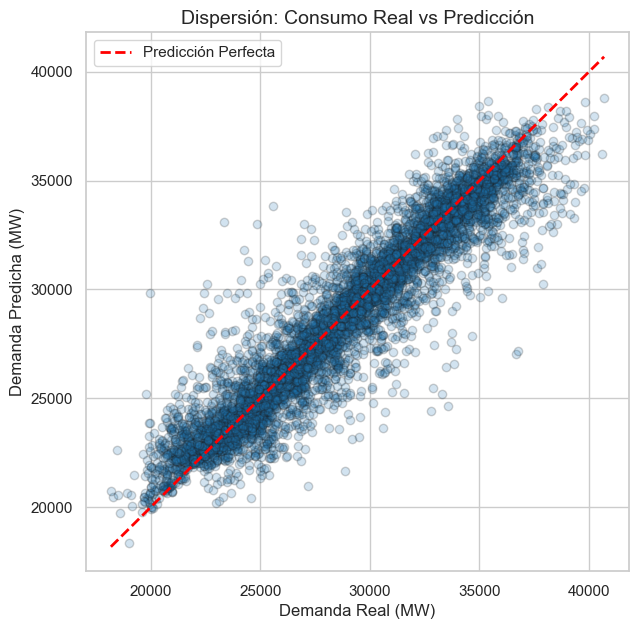

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final, alpha=0.2, color='#1f77b4', edgecolor='k')

# Línea de predicción perfecta
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Predicción Perfecta")

plt.title("Dispersión: Consumo Real vs Predicción", fontsize=14)
plt.filename = "dispersion.png"
plt.xlabel("Demanda Real (MW)", fontsize=12)
plt.ylabel("Demanda Predicha (MW)", fontsize=12)
plt.legend()
plt.show()

**Conclusión del gráfico:**
La nube de puntos se ajusta muchísimo a la diagonal roja, lo que confirma de forma visual ese $R^2$ del ~89% que conseguimos en las métricas. Además, vemos que el modelo es muy estable: la línea se mantiene compacta tanto en consumos bajos como altos, lo que significa que el modelo no sobreestima la demanda cuando hay picos de consumo.

### 7.3. Zoom Temporal: Simulación de una Semana Completa

Para ver cómo funcionaría el modelo en el día a día de Red Eléctrica, en la primera semana del test. Pintamos la línea real en negro y la predicción de nuestro XGBoost en naranja.

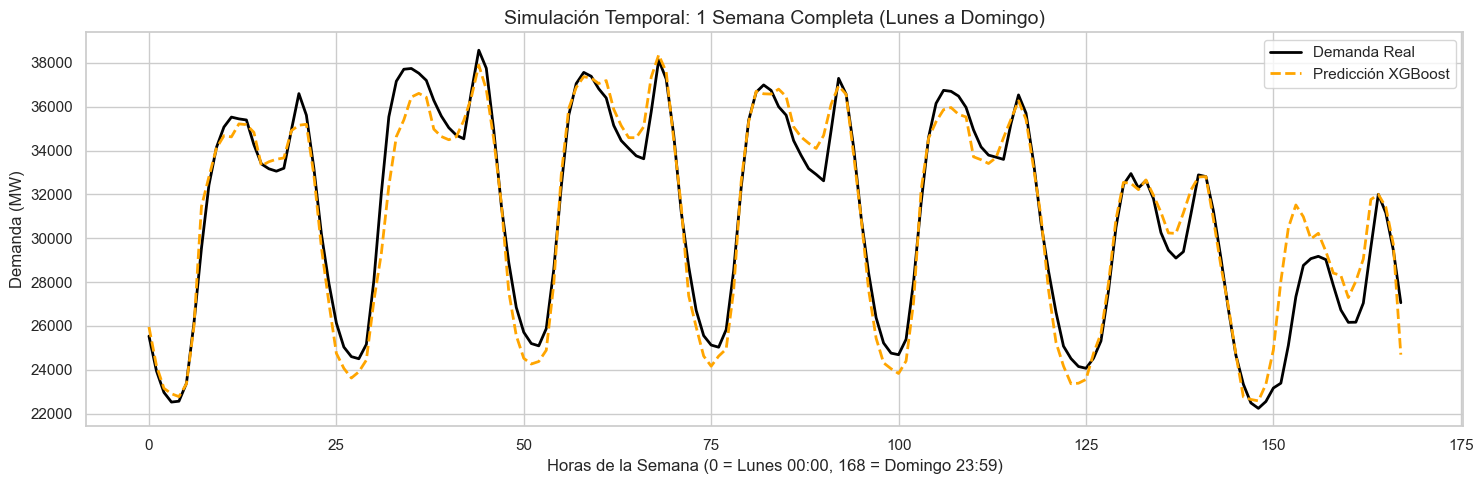

In [13]:
# Buscamos el primer Lunes en el conjunto de test (day_of_week == 0)
# Así nos aseguramos de que el gráfico siempre empieza en Lunes y acaba en Domingo.
primer_lunes_idx = test_df[test_df['day_of_week'] == 0].index[0]

# Extraemos las 168 horas (1 semana) a partir de ese lunes
semana_test_df = test_df.loc[primer_lunes_idx : primer_lunes_idx + 167]

semana_real = semana_test_df['total_load_actual'].values

# Buscamos qué posiciones (índices numéricos) corresponden en X_test_final
posicion_inicio = test_df.index.get_loc(primer_lunes_idx)
semana_pred = y_pred_final[posicion_inicio : posicion_inicio + 168]

plt.figure(figsize=(15, 5))
plt.plot(semana_real, label='Demanda Real', color='black', linewidth=2)
plt.plot(semana_pred, label='Predicción XGBoost', color='orange', linestyle='--', linewidth=2)

plt.title("Simulación Temporal: 1 Semana Completa (Lunes a Domingo)", fontsize=14)
plt.xlabel("Horas de la Semana (0 = Lunes 00:00, 168 = Domingo 23:59)", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusión del gráfico:**
Esta gráfica es fundamental para entender cómo el modelo "respira" al ritmo de la sociedad. Al aislar una semana completa (de lunes a domingo), vemos que la línea naranja calca casi a la perfección los patrones de los días laborables: detecta la caída drástica de madrugada, el pico de la mañana y el gran repunte de la tarde/noche cuando llegamos a casa.

Sin embargo, hay un detalle muy interesante al final del gráfico: **el domingo es el día donde la predicción se aleja un poco más de la línea real**. Esto tiene todo el sentido lógico. De lunes a viernes nuestra rutina como país es muy estricta (horarios de trabajo, colegios, industria funcionando a pleno rendimiento), lo que hace que los datos sean muy matemáticos. El domingo, en cambio, es un día impredecible: el consumo depende de si la gente se queda en casa, de si salen a comer o de si hace buen tiempo. Al ser un día con menos "rutina" y sin industria pesada, es totalmente normal que al modelo le cueste un poco más afinar el número exacto, aunque sigue captando perfectamente la bajada general del consumo.

### 7.4. Distribución de los Errores

Por último, analizamos los "residuos", que es simplemente restar el consumo real menos lo que predijo el modelo. Queremos ver si cuando el modelo falla, lo hace por mucho o por poco, y si tiende a equivocarse siempre hacia el mismo lado.

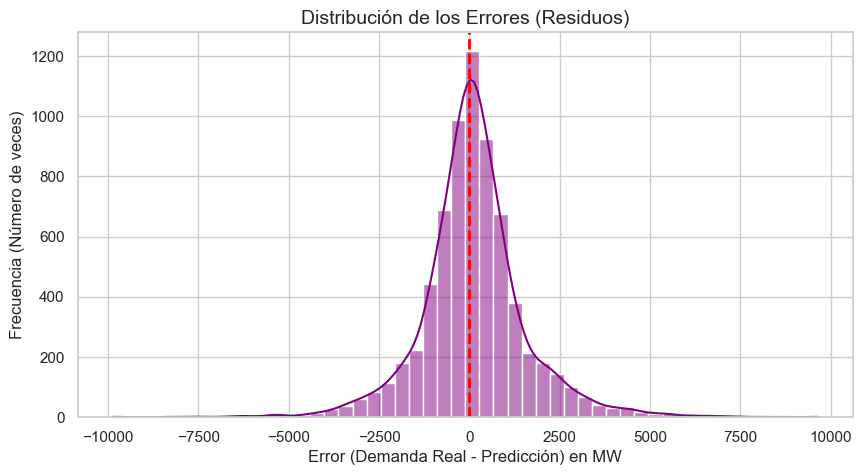

In [14]:
residuos = y_test.values.flatten() - y_pred_final

plt.figure(figsize=(10, 5))
sns.histplot(residuos, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.title("Distribución de los Errores (Residuos)", fontsize=14)
plt.xlabel("Error (Demanda Real - Predicción) en MW", fontsize=12)
plt.ylabel("Frecuencia (Número de veces)", fontsize=12)
plt.show()

**Conclusión del gráfico:**
Como vemos, los errores forman una campana perfecta centrada en el cero (el error ideal). Esto significa que la inmensa mayoría de las veces el error del modelo es minúsculo (está muy cerca de la línea roja del 0). Que tenga esta forma simétrica nos asegura que el modelo no tiene sesgos; es decir, no tiende a predecir sistemáticamente por encima ni por debajo de la realidad. Los fallos grandes son muy raros y aislados.